## Importing Dependencies

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Wisha's Dataset Constrained

In [2]:
filename = "./bigRun-t15-v3.hdf5"
output = "Output103"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "nodeLabelLMC",
    "basicTimeLastIsolated",
    "nodeIsIsolated",
    "satelliteBoundMass",
    "darkMatterProfileScale",
]

with h5py.File(filename, "r") as f:
    node_path = f"OutputsT/{output}/nodeData"
    out_path = f"OutputsT/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

constrained_df = pd.DataFrame(data)

tree_id = np.full(len(constrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

constrained_df["tree_id"] = tree_id

constrained_df["absolute_distance"] = np.linalg.norm(
    constrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)


constrained_df = constrained_df[constrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(constrained_df["nodeIsIsolated"].value_counts())
print(constrained_df["tree_id"].max())


Number of nodeData columns: 38

Columns being loaded:
satellitePositionX (3409274,) float64
satellitePositionY (3409274,) float64
satellitePositionZ (3409274,) float64
basicMass (3409274,) float64
nodeIndex (3409274,) int64
parentIndex (3409274,) int64
nodeLabelLMC (3409274,) int64
basicTimeLastIsolated (3409274,) float64
nodeIsIsolated (3409274,) int64
satelliteBoundMass (3409274,) float64
darkMatterProfileScale (3409274,) float64
nodeIsIsolated
0    3386888
Name: count, dtype: int64
1024


## Loading Wisha's Dataset Unconstrained

In [3]:
filename = "./bigRun-uncon-v3.hdf5"
output = "Output3"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "basicTimeLastIsolated",
    "nodeIsIsolated",
    "satelliteBoundMass",
    "darkMatterProfileScale",
]

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"
    out_path = f"Outputs/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

unconstrained_df = pd.DataFrame(data)

tree_id = np.full(len(unconstrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

unconstrained_df["tree_id"] = tree_id

unconstrained_df["absolute_distance"] = np.linalg.norm(
    unconstrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)


unconstrained_df = unconstrained_df[unconstrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(unconstrained_df["nodeIsIsolated"].value_counts())
print(unconstrained_df["tree_id"].max())


Number of nodeData columns: 36

Columns being loaded:
satellitePositionX (3272587,) float64
satellitePositionY (3272587,) float64
satellitePositionZ (3272587,) float64
basicMass (3272587,) float64
nodeIndex (3272587,) int64
parentIndex (3272587,) int64
basicTimeLastIsolated (3272587,) float64
nodeIsIsolated (3272587,) int64
satelliteBoundMass (3272587,) float64
darkMatterProfileScale (3272587,) float64
nodeIsIsolated
0    3271563
Name: count, dtype: int64
1024


## Constants

In [4]:
min_smc_mass = 5.0e9
max_smc_mass = 8.0e9

min_smc_distance = 0.02
max_smc_distance = 0.04

total_tree_count = len(tree_start)
print(f"Total number of merger trees: {total_tree_count}")

Total number of merger trees: 1024


## Finding SMC Candidates In Constrained Data

In [5]:
smc_candidate_mask = (
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

selected = constrained_df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))


Index(['satellitePositionX', 'satellitePositionY', 'satellitePositionZ',
       'basicMass', 'nodeIndex', 'parentIndex', 'nodeLabelLMC',
       'basicTimeLastIsolated', 'nodeIsIsolated', 'satelliteBoundMass',
       'darkMatterProfileScale', 'tree_id', 'absolute_distance'],
      dtype='str')
Selected tree IDs: [1009, 995, 995, 995, 1014, 1010, 980, 977, 972, 1023, 1011, 999, 1000, 966, 993, 1005, 1005, 996, 985, 985, 1021, 987, 982, 1006, 1006, 961, 981, 1019, 1007, 1003, 1003, 1022, 974, 971, 967, 983, 979, 990, 990, 990, 990, 1017, 1004, 1013, 992, 992, 984, 984, 958, 959, 959, 936, 948, 944, 951, 956, 952, 952, 952, 934, 934, 934, 934, 954, 929, 949, 927, 935, 921, 925, 923, 920, 922, 922, 918, 918, 910, 913, 900, 906, 901, 908, 902, 902, 899, 939, 883, 878, 887, 877, 877, 888, 867, 867, 886, 869, 879, 868, 882, 881, 881, 875, 866, 863, 860, 862, 864, 861, 855, 857, 852, 852, 852, 858, 853, 845, 850, 847, 847, 836, 849, 843, 846, 842, 835, 838, 834, 841, 829, 830, 830, 826, 819, 81

## SMC Candidates of trees with Multiple Candidates

In [6]:
special_smc_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_multiple_candidates)) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

special_candidates = constrained_df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 363


## SMC Candidates from trees with only one SMC

In [7]:
regular_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_single_candidate)) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

regular_candidates = constrained_df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 387


## Histograms of Infall times of Regular Candidates vs Special Candidates

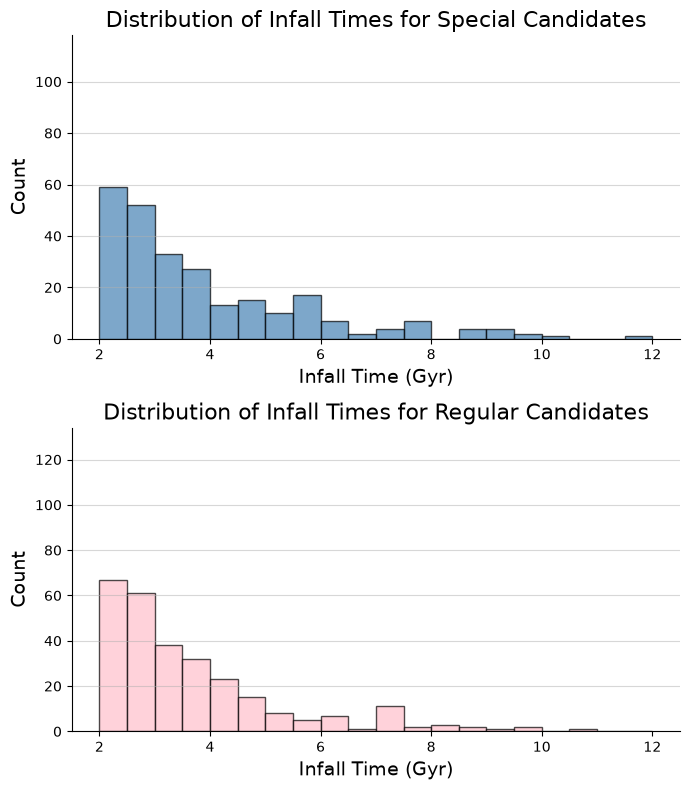

In [8]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Distribution of Infall Times for Special Candidates", fontsize=16)
ax[0].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Distribution of Infall Times for Regular Candidates", fontsize=16)
ax[1].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

